In [380]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, learning_curve, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer


In [381]:
# Load the dataset
df = pd.read_csv("labeled_data.csv")
df.head(5)


,ID,Item Code,Quantity_Sold_(kilo),Unit Selling Price (RMB/kg),Item Name_x,Category Code,Category Name,Wholesale Price (RMB/kg),Item Name_y,Loss Rate (%),Weekday
0,1,102900005115762,6.841,6.00,Amaranth,1011010101,Flower/Leaf Vegetables,3.88,Amaranth,18.52,Wednesday
1,21,102900005117209,1.909,16.00,7 Colour Pepper (1),1011010504,Capsicum,7.58,7 Colour Pepper (1),15.98,Wednesday
2,22,102900005118817,5.472,14.00,Spinach,1011010101,Flower/Leaf Vegetables,8.47,Spinach,18.51,Wednesday
3,23,102900005118824,4.119,10.00,High Melon (1),1011010402,Aquatic Tuberous Vegetables,5.65,High Melon (1),29.25,Wednesday
4,24,102900005118831,10.000,6.85,Wawacai,1011010101,Flower/Leaf Vegetables,4.13,Wawacai,2.48,Wednesday


In [382]:
df.columns

Index(['ID', 'Item Code', 'Quantity_Sold_(kilo)',
       'Unit Selling Price (RMB/kg)', 'Item Name_x', 'Category Code',
       'Category Name', 'Wholesale Price (RMB/kg)', 'Item Name_y',
       'Loss Rate (%)', 'Weekday'],
      dtype='str')

In [383]:
print(df.info())


<class 'pandas.DataFrame'>
RangeIndex: 32619 entries, 0 to 32618
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           32619 non-null  int64  
 1   Item Code                    32619 non-null  int64  
 2   Quantity_Sold_(kilo)         32619 non-null  float64
 3   Unit Selling Price (RMB/kg)  32619 non-null  float64
 4   Item Name_x                  32619 non-null  str    
 5   Category Code                32619 non-null  int64  
 6   Category Name                32619 non-null  str    
 7   Wholesale Price (RMB/kg)     30941 non-null  float64
 8   Item Name_y                  32619 non-null  str    
 9   Loss Rate (%)                32619 non-null  float64
 10  Weekday                      32619 non-null  str    
dtypes: float64(4), int64(3), str(4)
memory usage: 2.7 MB
None


In [384]:
duplicate_cols = []

for i in range(len(df.columns)):
    for j in range(i + 1, len(df.columns)):
        if df.iloc[:, i].equals(df.iloc[:, j]):
            duplicate_cols.append((df.columns[i], df.columns[j]))

print(duplicate_cols)

[('Item Name_x', 'Item Name_y')]


In [385]:
# Remove duplicate records
df1 = df.drop(columns=['Item Name_y'])
df1.columns

Index(['ID', 'Item Code', 'Quantity_Sold_(kilo)',
       'Unit Selling Price (RMB/kg)', 'Item Name_x', 'Category Code',
       'Category Name', 'Wholesale Price (RMB/kg)', 'Loss Rate (%)',
       'Weekday'],
      dtype='str')

In [386]:
# Standardize formats: Text casing
df1.columns = (
    df1.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
)
df1.head()

,id,item_code,quantity_sold_(kilo),unit_selling_price_(rmb/kg),item_name_x,category_code,category_name,wholesale_price_(rmb/kg),loss_rate_(%),weekday
0,1,102900005115762,6.841,6.00,Amaranth,1011010101,Flower/Leaf Vegetables,3.88,18.52,Wednesday
1,21,102900005117209,1.909,16.00,7 Colour Pepper (1),1011010504,Capsicum,7.58,15.98,Wednesday
2,22,102900005118817,5.472,14.00,Spinach,1011010101,Flower/Leaf Vegetables,8.47,18.51,Wednesday
3,23,102900005118824,4.119,10.00,High Melon (1),1011010402,Aquatic Tuberous Vegetables,5.65,29.25,Wednesday
4,24,102900005118831,10.000,6.85,Wawacai,1011010101,Flower/Leaf Vegetables,4.13,2.48,Wednesday


In [387]:
#Fix incorrect or inconsistent values
num_cols = df1.select_dtypes(include='number').columns

df1[num_cols] = df1[num_cols].clip(lower=0)
df1.head()

,id,item_code,quantity_sold_(kilo),unit_selling_price_(rmb/kg),item_name_x,category_code,category_name,wholesale_price_(rmb/kg),loss_rate_(%),weekday
0,1,102900005115762,6.841,6.00,Amaranth,1011010101,Flower/Leaf Vegetables,3.88,18.52,Wednesday
1,21,102900005117209,1.909,16.00,7 Colour Pepper (1),1011010504,Capsicum,7.58,15.98,Wednesday
2,22,102900005118817,5.472,14.00,Spinach,1011010101,Flower/Leaf Vegetables,8.47,18.51,Wednesday
3,23,102900005118824,4.119,10.00,High Melon (1),1011010402,Aquatic Tuberous Vegetables,5.65,29.25,Wednesday
4,24,102900005118831,10.000,6.85,Wawacai,1011010101,Flower/Leaf Vegetables,4.13,2.48,Wednesday


In [388]:
df1.columns

Index(['id', 'item_code', 'quantity_sold_(kilo)',
       'unit_selling_price_(rmb/kg)', 'item_name_x', 'category_code',
       'category_name', 'wholesale_price_(rmb/kg)', 'loss_rate_(%)',
       'weekday'],
      dtype='str')

In [389]:
#Handling missing values first before defining feature because of the new column i want to generate
df1["wholesale_price_(rmb/kg)"] = df1["wholesale_price_(rmb/kg)"].fillna(df1["wholesale_price_(rmb/kg)"].mean())


In [390]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 32619 entries, 0 to 32618
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           32619 non-null  int64  
 1   item_code                    32619 non-null  int64  
 2   quantity_sold_(kilo)         32619 non-null  float64
 3   unit_selling_price_(rmb/kg)  32619 non-null  float64
 4   item_name_x                  32619 non-null  str    
 5   category_code                32619 non-null  int64  
 6   category_name                32619 non-null  str    
 7   wholesale_price_(rmb/kg)     32619 non-null  float64
 8   loss_rate_(%)                32619 non-null  float64
 9   weekday                      32619 non-null  str    
dtypes: float64(4), int64(3), str(3)
memory usage: 2.5 MB


In [391]:
num_cols = df1.select_dtypes(include=["int64", "float64"]).columns

for col in num_cols:
    Q1 = df1[col].quantile(0.25)
    Q3 = df1[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df1[(df1[col] < lower) | (df1[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

id: 0 outliers
item_code: 3623 outliers
quantity_sold_(kilo): 2691 outliers
unit_selling_price_(rmb/kg): 1148 outliers
category_code: 3241 outliers
wholesale_price_(rmb/kg): 1739 outliers
loss_rate_(%): 1131 outliers


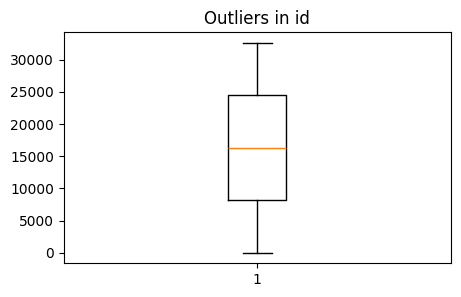

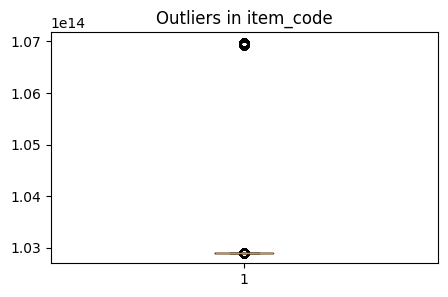

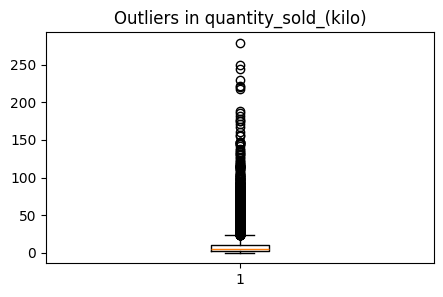

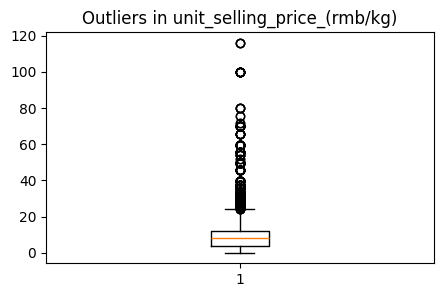

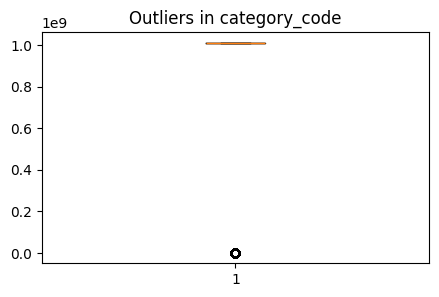

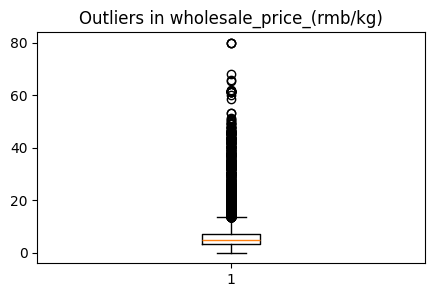

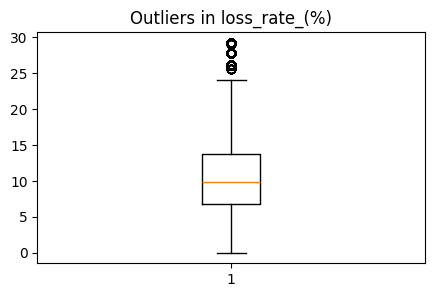

In [392]:
for col in num_cols:
    plt.figure(figsize=(5,3))
    plt.boxplot(df1[col].dropna())
    plt.title(f"Outliers in {col}")
    plt.show()

In [393]:
#outliers in ID, Item code, category code are ignored.
#For loss Rate the values will be capped ay 25%

df1["loss_rate_(%)"] = df1["loss_rate_(%)"].clip(0, 25)


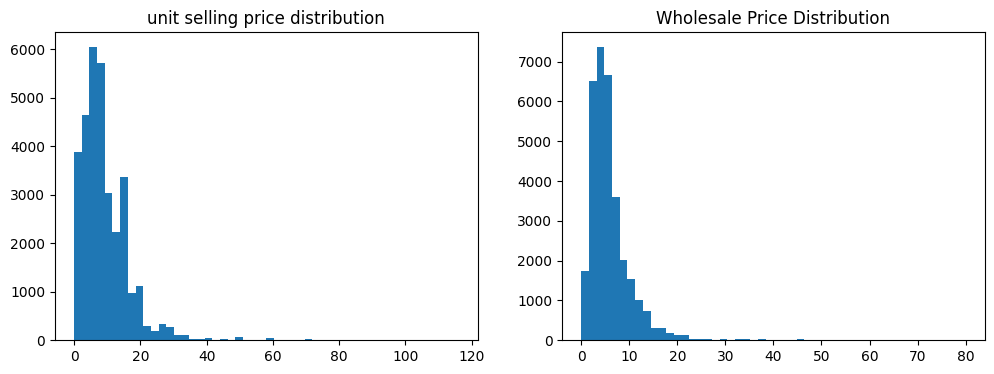

In [394]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.hist(df1["unit_selling_price_(rmb/kg)"], bins=50)
plt.title("unit selling price distribution")

plt.subplot(1,2,2)
plt.hist(df1["wholesale_price_(rmb/kg)"], bins=50)
plt.title("Wholesale Price Distribution")

plt.show()

In [395]:
#handling the outliers
#Limiting the extreme values withou deleting them because the outliers might not necessarily be errors might be due to expensive goods.
#for Unit selling price
q1 = df1["unit_selling_price_(rmb/kg)"].quantile(0.25)
q3 = df1["unit_selling_price_(rmb/kg)"].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

df1["unit_selling_price_(rmb/kg)"] = df1["unit_selling_price_(rmb/kg)"].clip(lower, upper)


In [396]:
#For wholesale price outliers
q1 = df1["wholesale_price_(rmb/kg)"].quantile(0.25)
q3 = df1["wholesale_price_(rmb/kg)"].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

df1["wholesale_price_(rmb/kg)"] = df1["wholesale_price_(rmb/kg)"].clip(lower, upper)


In [397]:
#feature engineering
df1["Profit_per_kg"] = df1["unit_selling_price_(rmb/kg)"] - df1["wholesale_price_(rmb/kg)"]

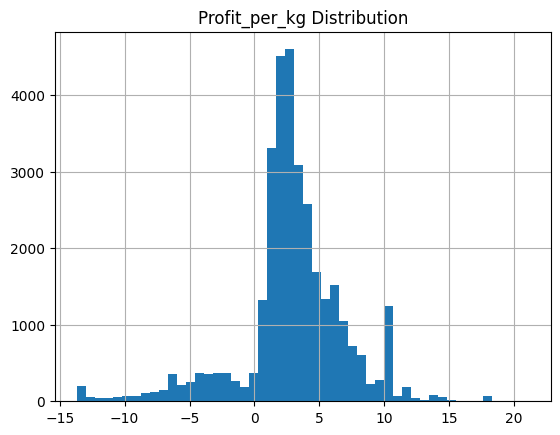

In [398]:
#To visualise the outliers and show the skeeness of the distribution
df1["Profit_per_kg"].hist(bins=50)
plt.title("Profit_per_kg Distribution")
plt.show()

In [399]:
#To determine the sum of outliers in the new feature
Q1 = df1["Profit_per_kg"].quantile(0.25)
Q3 = df1["Profit_per_kg"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df1[
    (df1["Profit_per_kg"] < lower) |
    (df1["Profit_per_kg"] > upper)
]

print("Number of outliers:", len(outliers))

Number of outliers: 4305


In [400]:
#To handle the skewness by cappping the tails to remove extreme data in the new column
lower = df1["Profit_per_kg"].quantile(0.01)
upper = df1["Profit_per_kg"].quantile(0.99)

df1["Profit_per_kg"] = df1["Profit_per_kg"].clip(lower, upper)

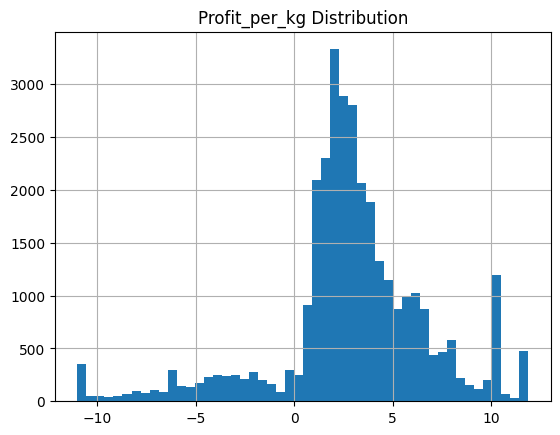

In [401]:
df1["Profit_per_kg"].hist(bins=50)
plt.title("Profit_per_kg Distribution")
plt.show()

## Training the model

In [402]:
# Defining target and features
features = ['category_name','Profit_per_kg','loss_rate_(%)','unit_selling_price_(rmb/kg)']
X_m = df1[features]
y = df1['quantity_sold_(kilo)']


In [403]:
#defining the variables as categorical and numerical
cat_cols = ['category_name']
num_cols = ['Profit_per_kg','loss_rate_(%)','unit_selling_price_(rmb/kg)']

In [404]:
# 60% Train, 20% Val, 20% Test
X_train, X_temp, y_train, y_temp = train_test_split(X_m, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print(f"Train size: {len(X_train)} | Val size: {len(X_val)} | Test size: {len(X_test)}")

Train size: 19571 | Val size: 6524 | Test size: 6524


In [405]:
#Handling the categorical variables by implemening different encoding strategies
from sklearn.preprocessing import OneHotEncoder

# One-Hot Encoding
ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train_cat = ohe.fit_transform(X_train[cat_cols])
X_val_cat = ohe.transform(X_val[cat_cols])
X_test_cat = ohe.transform(X_test[cat_cols])

 #Combine with numeric features
X_train_ohe = np.hstack([X_train[num_cols].values, X_train_cat])
X_val_ohe = np.hstack([X_val[num_cols].values, X_val_cat])
X_test_ohe = np.hstack([X_test[num_cols].values, X_test_cat])


In [406]:
# Ordinal Encoding
from sklearn.preprocessing import OrdinalEncoder

ord_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_train_cat = ord_enc.fit_transform(X_train[cat_cols])
X_val_cat = ord_enc.transform(X_val[cat_cols])
X_test_cat = ord_enc.transform(X_test[cat_cols])

# Combine with numeric features
X_train_ord = np.hstack([X_train[num_cols].values, X_train_cat])
X_val_ord = np.hstack([X_val[num_cols].values, X_val_cat])
X_test_ord = np.hstack([X_test[num_cols].values, X_test_cat])

In [407]:
#Frequency Ecoding 
#creating frequency maps from TRAIN ONLY
freq_map_cat = X_train['category_name'].value_counts(normalize=True)

# Copying  datasets
X_train_freq = X_train.copy()
X_val_freq = X_val.copy()
X_test_freq = X_test.copy()

X_train_freq['category_name'] = X_train['category_name'].map(freq_map_cat)
X_val_freq['category_name'] = X_val['category_name'].map(freq_map_cat).fillna(0)
X_test_freq['category_name'] = X_test['category_name'].map(freq_map_cat).fillna(0)



# Final datasets (already include numeric columns)
X_train_freq = X_train_freq[num_cols + cat_cols]
X_val_freq = X_val_freq[num_cols + cat_cols]
X_test_freq = X_test_freq[num_cols + cat_cols]



In [408]:
#Using Pipeline to reduce messy flow
ohe_preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

ohe_model = Pipeline(steps=[
    ('preprocess', ohe_preprocess),
    ('regressor', LinearRegression())
])


In [409]:
ord_preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols)
    ]
)

ord_model = Pipeline(steps=[
    ('preprocess', ord_preprocess),
    ('regressor', LinearRegression())
])

In [410]:
from sklearn.base import BaseEstimator, TransformerMixin

class FrequencyEncoder(BaseEstimator, TransformerMixin):
    
    def fit(self, X, y=None):
        self.freq_map = X.iloc[:, 0].value_counts(normalize=True).to_dict()
        return self

    def transform(self, X):
        return X.iloc[:, 0].map(self.freq_map).fillna(0).values.reshape(-1, 1)

In [411]:
freq_preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', FrequencyEncoder(), cat_cols)
    ]
)

freq_model = Pipeline(steps=[
    ('preprocess', freq_preprocess),
    ('regressor', LinearRegression())
])


## Model Evaluation

In [412]:
def evaluate(name, model, X_train, X_val):
    
    model.fit(X_train, y_train)
    
    preds = model.predict(X_val)
    
    return {
        "Strategy": name,
        "Features": "Pipeline",
        "Val MSE": mean_squared_error(y_val, preds),
        "Val R2": r2_score(y_val, preds)
    }


results = [
    evaluate("One-Hot", ohe_model, X_train, X_val),
    evaluate("Ordinal", ord_model, X_train, X_val),
    evaluate("Frequency", freq_model, X_train, X_val),
]

results_df = pd.DataFrame(results).sort_values("Val MSE")
print(results_df)

    Strategy  Features     Val MSE    Val R2
0    One-Hot  Pipeline  127.813018  0.113301
1    Ordinal  Pipeline  135.104351  0.062717
2  Frequency  Pipeline  137.368639  0.047009


In [413]:
from sklearn.preprocessing import PolynomialFeatures

poly_ohe_model = Pipeline(steps=[
    ('preprocess', ColumnTransformer(
        transformers=[
           ('num', Pipeline(steps=[
               ('poly', PolynomialFeatures(degree=2, include_bias=False)),
                ('scaler', StandardScaler())
          ]), num_cols),

            ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
        ]
    )),
    ('regressor', LinearRegression())
])

In [414]:
poly_ohe_model.fit(X_train, y_train)

val_preds = poly_ohe_model.predict(X_val)

print("Val MSE:", mean_squared_error(y_val, val_preds))
print("Val R2:", r2_score(y_val, val_preds))

Val MSE: 123.96450034516975
Val R2: 0.1399998406255597


In [415]:
from sklearn.tree import DecisionTreeRegressor

depths = [1, 2, 3, 5, 7, 10, 15, 20, 30, None]
val_scores = []
val_mse_scores = []


for d in depths:
    
    model = Pipeline(steps=[
        ('preprocess', ColumnTransformer(
            transformers=[
                ('num', 'passthrough', num_cols),
                ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
            ]
        )),
        ('regressor', DecisionTreeRegressor(max_depth=d, random_state=42))
    ])
    
    model.fit(X_train, y_train)

    y_val_pred = model.predict(X_val)

    r2 = r2_score(y_val, y_val_pred)
    mse = mean_squared_error(y_val, y_val_pred)

    val_scores.append(r2)
    val_mse_scores.append(mse)

    depth_label = str(d) if d is not None else "None"
    print(f"max_depth = {depth_label:>4s} → R² = {r2:.4f} | MSE = {mse:.4f}")

max_depth =    1 → R² = 0.0597 | MSE = 135.5326
max_depth =    2 → R² = 0.1027 | MSE = 129.3443
max_depth =    3 → R² = 0.1229 | MSE = 126.4237
max_depth =    5 → R² = 0.3030 | MSE = 100.4679
max_depth =    7 → R² = 0.4413 | MSE = 80.5370
max_depth =   10 → R² = 0.4600 | MSE = 77.8325
max_depth =   15 → R² = 0.4355 | MSE = 81.3711
max_depth =   20 → R² = 0.3493 | MSE = 93.8005
max_depth =   30 → R² = 0.3115 | MSE = 99.2508
max_depth = None → R² = 0.3059 | MSE = 100.0494


In [416]:
depths = [1, 2, 3, 5, 7, 10, 15, 20, 30, None]
leaf_sizes = [1, 5, 10, 20]

best_score = -np.inf
best_params = None

In [417]:
for d in depths:
    for leaf in leaf_sizes:
        
        model = Pipeline(steps=[
            ('preprocess', ColumnTransformer(
                transformers=[
                    ('num', 'passthrough', num_cols),
                    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
                ]
            )),
            ('regressor', DecisionTreeRegressor(
                max_depth=d,
                min_samples_leaf=leaf,
                random_state=42
            ))
        ])
        
        model.fit(X_train, y_train)

        y_val_pred = model.predict(X_val)

        r2 = r2_score(y_val, y_val_pred)
        mse = mean_squared_error(y_val, y_val_pred)

         # store results
        results.append([d, leaf, r2, mse])

        # track best model
        if r2 > best_score:
            best_score = r2
            best_params = (d, leaf)
            best_model = model

        print(f"depth={d}, leaf={leaf} → R²={r2:.4f} | MSE={mse:.4f}")

        

depth=1, leaf=1 → R²=0.0597 | MSE=135.5326
depth=1, leaf=5 → R²=0.0597 | MSE=135.5326
depth=1, leaf=10 → R²=0.0597 | MSE=135.5326
depth=1, leaf=20 → R²=0.0597 | MSE=135.5326
depth=2, leaf=1 → R²=0.1027 | MSE=129.3443
depth=2, leaf=5 → R²=0.1027 | MSE=129.3443
depth=2, leaf=10 → R²=0.1027 | MSE=129.3443
depth=2, leaf=20 → R²=0.1027 | MSE=129.3443
depth=3, leaf=1 → R²=0.1229 | MSE=126.4237
depth=3, leaf=5 → R²=0.1229 | MSE=126.4237
depth=3, leaf=10 → R²=0.1228 | MSE=126.4457
depth=3, leaf=20 → R²=0.1228 | MSE=126.4457
depth=5, leaf=1 → R²=0.3030 | MSE=100.4679
depth=5, leaf=5 → R²=0.3040 | MSE=100.3311
depth=5, leaf=10 → R²=0.3047 | MSE=100.2240
depth=5, leaf=20 → R²=0.3049 | MSE=100.1916
depth=7, leaf=1 → R²=0.4413 | MSE=80.5370
depth=7, leaf=5 → R²=0.4425 | MSE=80.3622
depth=7, leaf=10 → R²=0.4371 | MSE=81.1365
depth=7, leaf=20 → R²=0.4472 | MSE=79.6803
depth=10, leaf=1 → R²=0.4600 | MSE=77.8325
depth=10, leaf=5 → R²=0.5212 | MSE=69.0189
depth=10, leaf=10 → R²=0.5171 | MSE=69.6085
dept

In [418]:
from sklearn.ensemble import RandomForestRegressor

preprocess = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

In [419]:
rf_model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('regressor', RandomForestRegressor(
        n_estimators=200,
        max_depth=20,
        min_samples_leaf=20,
        random_state=42,
        n_jobs=-1
    ))
])

In [420]:
rf_model.fit(X_train, y_train)

val_preds = rf_model.predict(X_val)

val_mse = mean_squared_error(y_val, val_preds)
val_r2 = r2_score(y_val, val_preds)

print("Validation MSE:", val_mse)
print("Validation R2:", val_r2)

Validation MSE: 62.57420315182583
Validation R2: 0.5658932635273946


In [421]:
best_r2 = -np.inf
best_params = None

best_mse = np.inf  # optional but useful

results = []

for n in [100, 200,300]:
    for d in [12, 15, 18, 20]:
        for leaf in [5, 8, 10, 12, 15]:
            for mf in ['sqrt', 0.5, 0.7]:

                rf_model = Pipeline(steps=[
                    ('preprocess', preprocess),
                    ('regressor', RandomForestRegressor(
                        n_estimators=n,
                        max_depth=d,
                        min_samples_leaf=leaf,
                        max_features=mf,
                        random_state=42,
                        n_jobs=-1
                    ))
                ])

                rf_model.fit(X_train, y_train)
                val_preds = rf_model.predict(X_val)

                r2 = r2_score(y_val, val_preds)
                mse = mean_squared_error(y_val, val_preds)

                # store all results (for analysis later)
                results.append([n, d, leaf, mf, r2, mse])

                if r2 > best_r2:
                    best_r2 = r2
                    best_params = (n, d, leaf, mf)

print("Best R2:", best_r2)
print("Best params:", best_params)

Best R2: 0.6021462264906626
Best params: (300, 20, 5, 0.5)


In [422]:
best_rf_model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('regressor', RandomForestRegressor(
        n_estimators=300,
        max_depth=20,
        min_samples_leaf=5,
        max_features=0.5,
        random_state=42,
        n_jobs=-1
    ))
])

# Train on full training data
best_rf_model.fit(X_train, y_train)

# Predict on test set
test_preds = best_rf_model.predict(X_test)

# Metrics
test_r2 = r2_score(y_test, test_preds)
test_mse = mean_squared_error(y_test, test_preds)
test_rmse = np.sqrt(test_mse)

print("FINAL TEST RESULTS (BEST RF)")
print("R2  :", test_r2)
print("MSE :", test_mse)
print("RMSE:", test_rmse)

FINAL TEST RESULTS (BEST RF)
R2  : 0.5768190146454119
MSE : 69.76332481683093
RMSE: 8.352444242066566


In [423]:
#Prediction on test set with best model 
test_preds = rf_model.predict(X_test)

test_mse = mean_squared_error(y_test, test_preds)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, test_preds)

print("FINAL TEST RESULTS (Random Forest)")
print("MSE :", test_mse)
print("RMSE:", test_rmse)
print("R2  :", test_r2)

FINAL TEST RESULTS (Random Forest)
MSE : 73.41574494349847
RMSE: 8.568298836029149
R2  : 0.5546636091771335


In [424]:
#train on the full data 
X_full = df1[features]
y_full = df1['quantity_sold_(kilo)']

best_rf_model.fit(X_full, y_full)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers 

In [ ]:
# Load the dataset
df_unlabeled = pd.read_csv("unlabeled_data.csv")
df_unlabeled.head(5)

,ID,Item Code,Unit Selling Price (RMB/kg),Item Name_x,Category Code,Category Name,Wholesale Price (RMB/kg),Item Name_y,Loss Rate (%),Weekday
0,32650,102900011033234,1.785714,Hongshujian (Bag),1011010101,Flower/Leaf Vegetables,0.75,Hongshujian (Bag),9.43,Sunday
1,32643,102900011032213,4.011111,Red Hang Pepper (Bag),1011010504,Capsicum,2.94,Red Hang Pepper (Bag),9.43,Sunday
2,32644,102900011032237,3.760870,Green Line Pepper (Bag),1011010504,Capsicum,1.54,Green Line Pepper (Bag),9.43,Sunday
3,32645,102900011032244,4.900000,Red Hot Peppers (Bag),1011010504,Capsicum,3.07,Red Hot Peppers (Bag),9.43,Sunday
4,32646,102900011032251,5.900000,Luosi Pepper (Bag),1011010504,Capsicum,2.14,Luosi Pepper (Bag),9.43,Sunday


In [436]:
# Remove duplicate records
df_unlabeled. columns 

Index(['ID', 'Item Code', 'Unit Selling Price (RMB/kg)', 'Item Name_x',
       'Category Code', 'Category Name', 'Wholesale Price (RMB/kg)',
       'Item Name_y', 'Loss Rate (%)', 'Weekday'],
      dtype='str')

In [437]:
# Standardize formats: Text casing
df_unlabeled.columns = (
   df_unlabeled.columns
    .str.strip()
    .str.lower()
    .str.replace(' ', '_')
)
df_unlabeled.head()

,id,item_code,unit_selling_price_(rmb/kg),item_name_x,category_code,category_name,wholesale_price_(rmb/kg),item_name_y,loss_rate_(%),weekday
0,32650,102900011033234,1.785714,Hongshujian (Bag),1011010101,Flower/Leaf Vegetables,0.75,Hongshujian (Bag),9.43,Sunday
1,32643,102900011032213,4.011111,Red Hang Pepper (Bag),1011010504,Capsicum,2.94,Red Hang Pepper (Bag),9.43,Sunday
2,32644,102900011032237,3.760870,Green Line Pepper (Bag),1011010504,Capsicum,1.54,Green Line Pepper (Bag),9.43,Sunday
3,32645,102900011032244,4.900000,Red Hot Peppers (Bag),1011010504,Capsicum,3.07,Red Hot Peppers (Bag),9.43,Sunday
4,32646,102900011032251,5.900000,Luosi Pepper (Bag),1011010504,Capsicum,2.14,Luosi Pepper (Bag),9.43,Sunday


In [450]:
df_unlabeled["Profit_per_kg"] = df_unlabeled["unit_selling_price_(rmb/kg)"] - df_unlabeled["wholesale_price_(rmb/kg)"]
df_unlabeled.head()


,id,item_code,unit_selling_price_(rmb/kg),item_name_x,category_code,category_name,wholesale_price_(rmb/kg),item_name_y,loss_rate_(%),weekday,profit_per_kg,Profit_per_kg
0,32650,102900011033234,1.785714,Hongshujian (Bag),1011010101,Flower/Leaf Vegetables,0.75,Hongshujian (Bag),9.43,Sunday,1.035714,1.035714
1,32643,102900011032213,4.011111,Red Hang Pepper (Bag),1011010504,Capsicum,2.94,Red Hang Pepper (Bag),9.43,Sunday,1.071111,1.071111
2,32644,102900011032237,3.760870,Green Line Pepper (Bag),1011010504,Capsicum,1.54,Green Line Pepper (Bag),9.43,Sunday,2.220870,2.220870
3,32645,102900011032244,4.900000,Red Hot Peppers (Bag),1011010504,Capsicum,3.07,Red Hot Peppers (Bag),9.43,Sunday,1.830000,1.830000
4,32646,102900011032251,5.900000,Luosi Pepper (Bag),1011010504,Capsicum,2.14,Luosi Pepper (Bag),9.43,Sunday,3.760000,3.760000


In [451]:

features = ['category_name','Profit_per_kg','loss_rate_(%)','unit_selling_price_(rmb/kg)']
X_full = df1[features]
y_full = df1['quantity_sold_(kilo)']

best_rf_model.fit(X_full, y_full)


# Prediction on unlabeled
X_unlabeled = df_unlabeled[features]
predictions = best_rf_model.predict(X_unlabeled)

# Create submission
submission = pd.DataFrame({
    "ID": df_unlabeled["id"], 
    "Quantity_Sold_(kilo)": predictions
})

# Save
submission.to_csv("my_predictions.csv", index=False)

In [ ]:
df_prediction = pd.read_csv("my_predictions.csv")
df_prediction.head(5)